In [11]:
import pandas as pd 
data = pd.read_csv('../results/YOLOworld/cerveza2_track/raw_detections.csv')
data['center_x'] = data['x1'] + (data['x2'] - data['x1']) / 2
data['center_y'] = data['y1'] + (data['y2'] - data['y1']) / 2
data = data[data['frame'] < 800]
data = data[data['class'] == 'cup']
coords = {}
for i,g in data.groupby('track_id'):
    coords[i] = g[['frame','center_x', 'center_y']].values
data.head()

,frame,time_s,class,confidence,track_id,x1,y1,x2,y2,center_x,center_y
0,0,0.00,cup,0.9210,1,78.97,629.55,176.96,868.88,127.965,749.215
1,0,0.00,cup,0.8470,2,356.84,665.33,520.23,924.70,438.535,795.015
2,0,0.00,cup,0.8137,3,181.65,553.71,293.56,708.53,237.605,631.120
4,1,0.05,cup,0.9161,1,78.99,629.52,176.83,868.89,127.910,749.205
5,1,0.05,cup,0.8455,2,356.69,665.33,520.16,924.69,438.425,795.010


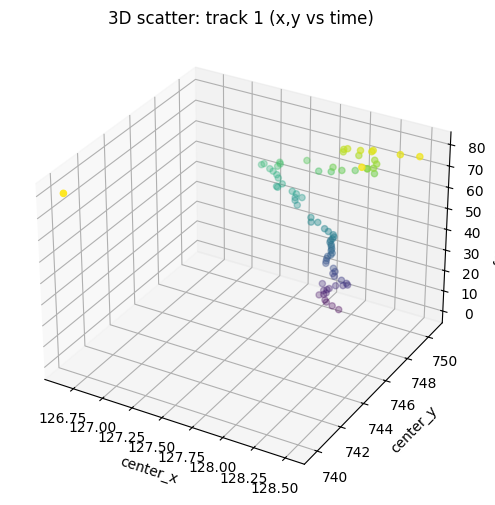

In [12]:


from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

track_id = 1  # or another id in coords
arr = coords[track_id]  # shape (n,3): [frame, center_x, center_y]
t = arr[:, 0]
x = arr[:, 1]
y = arr[:, 2]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, t, c=t, cmap='viridis', s=20)
ax.set_xlabel('center_x')
ax.set_ylabel('center_y')
ax.set_zlabel('frame / time')
ax.set_title(f'3D scatter: track {track_id} (x,y vs time)')
plt.show()

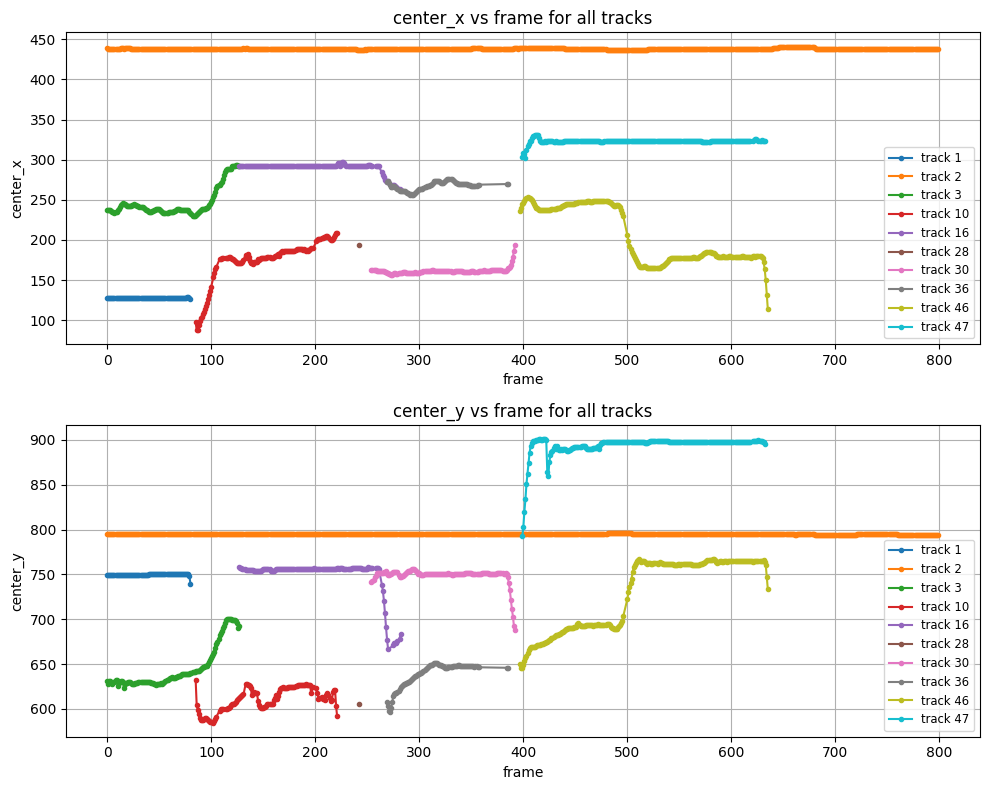

In [14]:
plt.figure(figsize=(10, 8))

# row 1: x vs frame
ax1 = plt.subplot(2, 1, 1)
for track_id, arr in coords.items():
    t = arr[:, 0]
    x = arr[:, 1]
    ax1.plot(t, x, marker='o', linestyle='-', label=f'track {track_id}', markersize=3)
ax1.set_xlabel('frame')
ax1.set_ylabel('center_x')
ax1.set_title('center_x vs frame for all tracks')
ax1.legend(fontsize='small', loc='best')
ax1.grid(True)

# row 2: y vs frame
ax2 = plt.subplot(2, 1, 2)
for track_id, arr in coords.items():
    t = arr[:, 0]
    y = arr[:, 2]
    ax2.plot(t, y, marker='o', linestyle='-', label=f'track {track_id}', markersize=3)
ax2.set_xlabel('frame')
ax2.set_ylabel('center_y')
ax2.set_title('center_y vs frame for all tracks')
ax2.legend(fontsize='small', loc='best')
ax2.grid(True)

plt.tight_layout()
plt.show()
